# ConvNeXt Tiny — Frozen Backbone + Segmentation Head

Architecture:
- **Backbone**: ConvNeXt Tiny (ImageNet-22k pretrained, **frozen**)
- **Decoder**: FPN-style head (**trainable only**)
- **Output**: 2-channel logits → binary segmentation (nerve fiber)

ConvNeXt Tiny feature stages:
| Stage | Channels | Resolution |
|-------|----------|------------|
| C1    | 96       | H/4        |
| C2    | 192      | H/8        |
| C3    | 384      | H/16       |
| C4    | 768      | H/32       |

In [1]:
import sys
import random
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neural_reconstruction.core.segmentation import (
    SegmentationLoss,
    PatchDataset,
    extract_patches,
    load_sample,
)

/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Config ────────────────────────────────────────────────────────────────
BASE_PATH   = Path('/home/pony/projects/ienf_q')
DATA_DIR    = BASE_PATH / 'data_0320'
OUTPUT_DIR  = BASE_PATH / 'output/convnext_seg'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATCH_SIZE  = 1024
OVERLAP     = 64
STRIDE      = PATCH_SIZE - OVERLAP
BATCH_SIZE  = 12
EPOCHS      = 100
LR          = 3e-4
TRAIN_RATIO = 0.8
SEED        = 42
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## Model

In [3]:
class FPNDecoder(nn.Module):
    """Top-down FPN decoder.

    Fuses multi-scale features from ConvNeXt Tiny:
      C4 (768, /32) -> C3 (384, /16) -> C2 (192, /8) -> C1 (96, /4)
    then 4× upsample to original resolution.

    All ops are trainable.
    """

    def __init__(
        self,
        feat_channels: list[int],  # [96, 192, 384, 768]
        fpn_channels: int = 256,
        num_classes: int = 2,
    ):
        super().__init__()
        # Lateral 1×1 convs: reduce each stage to fpn_channels
        self.lateral = nn.ModuleList([
            nn.Conv2d(c, fpn_channels, 1) for c in feat_channels
        ])
        # Output 3×3 convs after merge
        self.output_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(fpn_channels, fpn_channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(fpn_channels),
                nn.ReLU(inplace=True),
            )
            for _ in feat_channels
        ])
        # Final head: upsample from /4 to /1 with two 2× steps
        self.head = nn.Sequential(
            nn.Conv2d(fpn_channels, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, num_classes, 1),
        )

    def forward(self, features: list[torch.Tensor]) -> torch.Tensor:
        # features: [C1, C2, C3, C4], coarse to fine reversed below
        # Build FPN top-down: start from C4 (index 3)
        laterals = [l(f) for l, f in zip(self.lateral, features)]

        # Top-down merge
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(
                laterals[i], size=laterals[i - 1].shape[-2:],
                mode='bilinear', align_corners=False
            )
            laterals[i - 1] = laterals[i - 1] + upsampled

        # Apply output convs
        p = [conv(lat) for conv, lat in zip(self.output_convs, laterals)]

        # Use finest scale (P1, /4) as input to final head
        return self.head(p[0])


class ConvNeXtSegModel(nn.Module):
    """ConvNeXt Tiny backbone (frozen) + FPN segmentation head (trainable).

    Input : (B, 1, H, W) — grayscale patch
    Output: (B, num_classes, H, W) — logits
    """

    def __init__(self, num_classes: int = 2, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model(
            'convnext_tiny.fb_in22k_ft_in1k',
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3),
        )
        # Freeze all backbone parameters
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.decoder = FPNDecoder([96, 192, 384, 768], num_classes=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Grayscale -> 3-channel (repeat)
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        features = self.backbone(x)  # list of [B, C, H, W]
        return self.decoder(features)


model = ConvNeXtSegModel(num_classes=2, pretrained=True).to(DEVICE)

n_frozen    = sum(p.numel() for p in model.backbone.parameters())
n_trainable = sum(p.numel() for p in model.decoder.parameters())
print(f'Backbone (frozen)  : {n_frozen / 1e6:.2f} M')
print(f'Decoder (trainable): {n_trainable / 1e6:.2f} M')

Backbone (frozen)  : 27.82 M
Decoder (trainable): 3.10 M


## Data

In [4]:
def find_valid_samples(data_dir: Path) -> list[Path]:
    required = ['image.png', 'annotation.png', 'label.png']
    return [
        d for d in sorted(data_dir.iterdir())
        if d.is_dir() and all((d / f).exists() for f in required)
    ]

def load_patches(dirs: list[Path], tag: str, workers: int = 4) -> list:
    results: dict[Path, list] = {}
    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {
            pool.submit(lambda d: (d, extract_patches(*load_sample(d), patch_size=PATCH_SIZE, stride=STRIDE)), d): d
            for d in dirs
        }
        for fut in as_completed(futures):
            d, patches = fut.result()
            results[d] = patches
            print(f'  [{tag}] {d.name}: {len(patches)} patches')
    patches_all = []
    for d in dirs:
        patches_all.extend(results[d])
    return patches_all

valid_samples = find_valid_samples(DATA_DIR)
print(f'Found {len(valid_samples)} samples')

shuffled = valid_samples.copy()
random.shuffle(shuffled)
n_train = max(1, int(len(shuffled) * TRAIN_RATIO))
train_dirs = shuffled[:n_train]
val_dirs   = shuffled[n_train:] or shuffled[:1]  # fallback if only 1 sample

print(f'Train: {[d.name for d in train_dirs]}')
print(f'Val:   {[d.name for d in val_dirs]}')

train_patches = load_patches(train_dirs, 'train')
val_patches   = load_patches(val_dirs,   'val')

# Class imbalance -> pos_weight
total_px = sum(p[2].size for p in train_patches)
fg_px    = sum(int((p[2] > 127).sum()) for p in train_patches)
pos_weight = min((total_px - fg_px) / max(fg_px, 1), 20.0)
print(f'\nBG {(total_px - fg_px) / total_px:.1%}  FG {fg_px / total_px:.1%}  pos_weight={pos_weight:.1f}')

train_ds = PatchDataset(train_patches, augment=True)
val_ds   = PatchDataset(val_patches,   augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=(DEVICE=='cuda'))
print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')

Found 17 samples
Train: ['S226-2_a', 'S236-2_b', 'S222-2_a', 'S222-2_b', 'S558-2_a', 'S487-2_b', 'S487-2_a', 'S236-2_a', 'S226-2_b', 'S1140-2_b', 'S1585-2_a', 'S341-2_b', 'S558-2_b']
Val:   ['S1616-2_a', 'S341-2_a', 'S1140-2_a', 'S1585-2_b']
  [train] S226-2_a: 14 patches
  [train] S222-2_a: 16 patches
  [train] S222-2_b: 16 patches
  [train] S236-2_b: 20 patches
  [train] S558-2_a: 24 patches
  [train] S487-2_b: 20 patches
  [train] S236-2_a: 20 patches
  [train] S487-2_a: 22 patches
  [train] S1140-2_b: 11 patches
  [train] S226-2_b: 18 patches
  [train] S1585-2_a: 14 patches
  [train] S341-2_b: 18 patches
  [train] S558-2_b: 17 patches
  [val] S1140-2_a: 9 patches
  [val] S1616-2_a: 17 patches
  [val] S1585-2_b: 11 patches
  [val] S341-2_a: 19 patches

BG 99.2%  FG 0.8%  pos_weight=20.0
Train batches: 20  Val batches: 5


## Training

In [5]:
criterion = SegmentationLoss(pos_weight=pos_weight, bce_weight=0.5, dice_weight=0.5).to(DEVICE)

# Only optimize decoder parameters
optimizer = optim.AdamW(model.decoder.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = dice_sum = n = 0
    with torch.set_grad_enabled(train):
        for x, y, _ in loader:          # _ = skeleton (unused)
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            # Dice metric
            prob = torch.softmax(logits, dim=1)[:, 1].detach()
            pred = (prob > 0.5).float()
            gt   = y.float()
            inter = (pred * gt).sum()
            denom = pred.sum() + gt.sum()
            dice_sum   += (2 * inter / (denom + 1e-6)).item()
            total_loss += loss.item()
            n += 1
    return total_loss / n, dice_sum / n


history = {'train_loss': [], 'val_loss': [], 'val_dice': []}
best_val_loss = float('inf')
ckpt_path = OUTPUT_DIR / 'convnext_seg_best.pth'

for epoch in range(1, EPOCHS + 1):
    t_loss, _      = run_epoch(train_loader, train=True)
    v_loss, v_dice = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_dice)

    marker = ''
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': history,
        }, ckpt_path)
        marker = ' <- best'

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{EPOCHS} | '
              f'Train {t_loss:.4f} | Val {v_loss:.4f} | Dice {v_dice:.4f} | '
              f'LR {lr:.2e}{marker}')

print(f'\nBest val loss: {best_val_loss:.4f}')
print(f'Checkpoint   : {ckpt_path}')

Epoch   1/100 | Train 0.8084 | Val 0.8649 | Dice 0.0710 | LR 3.00e-04 <- best
Epoch  10/100 | Train 0.4808 | Val 0.4843 | Dice 0.4333 | LR 2.93e-04 <- best
Epoch  20/100 | Train 0.3061 | Val 0.3628 | Dice 0.4922 | LR 2.71e-04
Epoch  30/100 | Train 0.2607 | Val 0.2933 | Dice 0.5660 | LR 2.38e-04 <- best
Epoch  40/100 | Train 0.2431 | Val 0.2764 | Dice 0.5899 | LR 1.97e-04 <- best
Epoch  50/100 | Train 0.2240 | Val 0.2742 | Dice 0.5895 | LR 1.50e-04
Epoch  60/100 | Train 0.2227 | Val 0.2768 | Dice 0.5788 | LR 1.04e-04
Epoch  70/100 | Train 0.2082 | Val 0.2726 | Dice 0.5949 | LR 6.26e-05
Epoch  80/100 | Train 0.2044 | Val 0.2701 | Dice 0.5997 | LR 2.96e-05
Epoch  90/100 | Train 0.2030 | Val 0.2669 | Dice 0.6022 | LR 8.32e-06
Epoch 100/100 | Train 0.2042 | Val 0.2664 | Dice 0.6030 | LR 1.00e-06

Best val loss: 0.2652
Checkpoint   : /home/pony/projects/ienf_q/output/convnext_seg/convnext_seg_best.pth


## Loss Curves

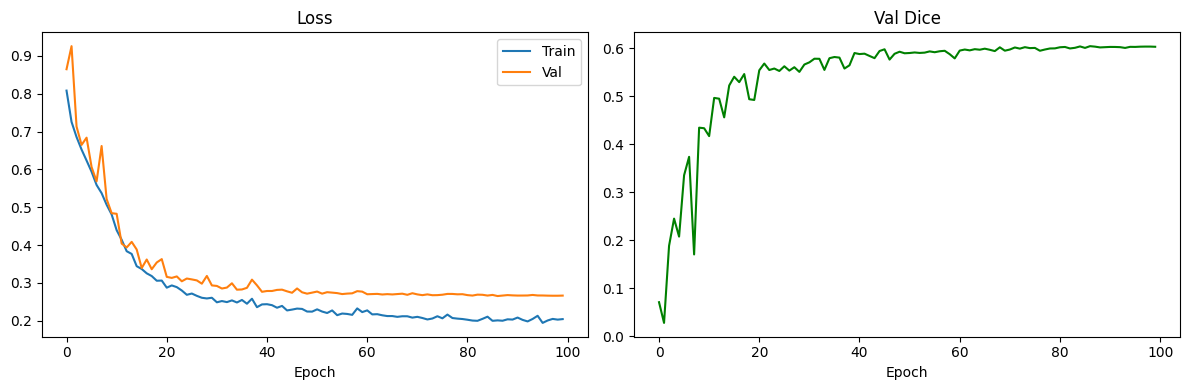

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_dice'], color='green')
axes[1].set_title('Val Dice')
axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'loss_curves.png', dpi=150)
plt.show()

## Prediction Visualization

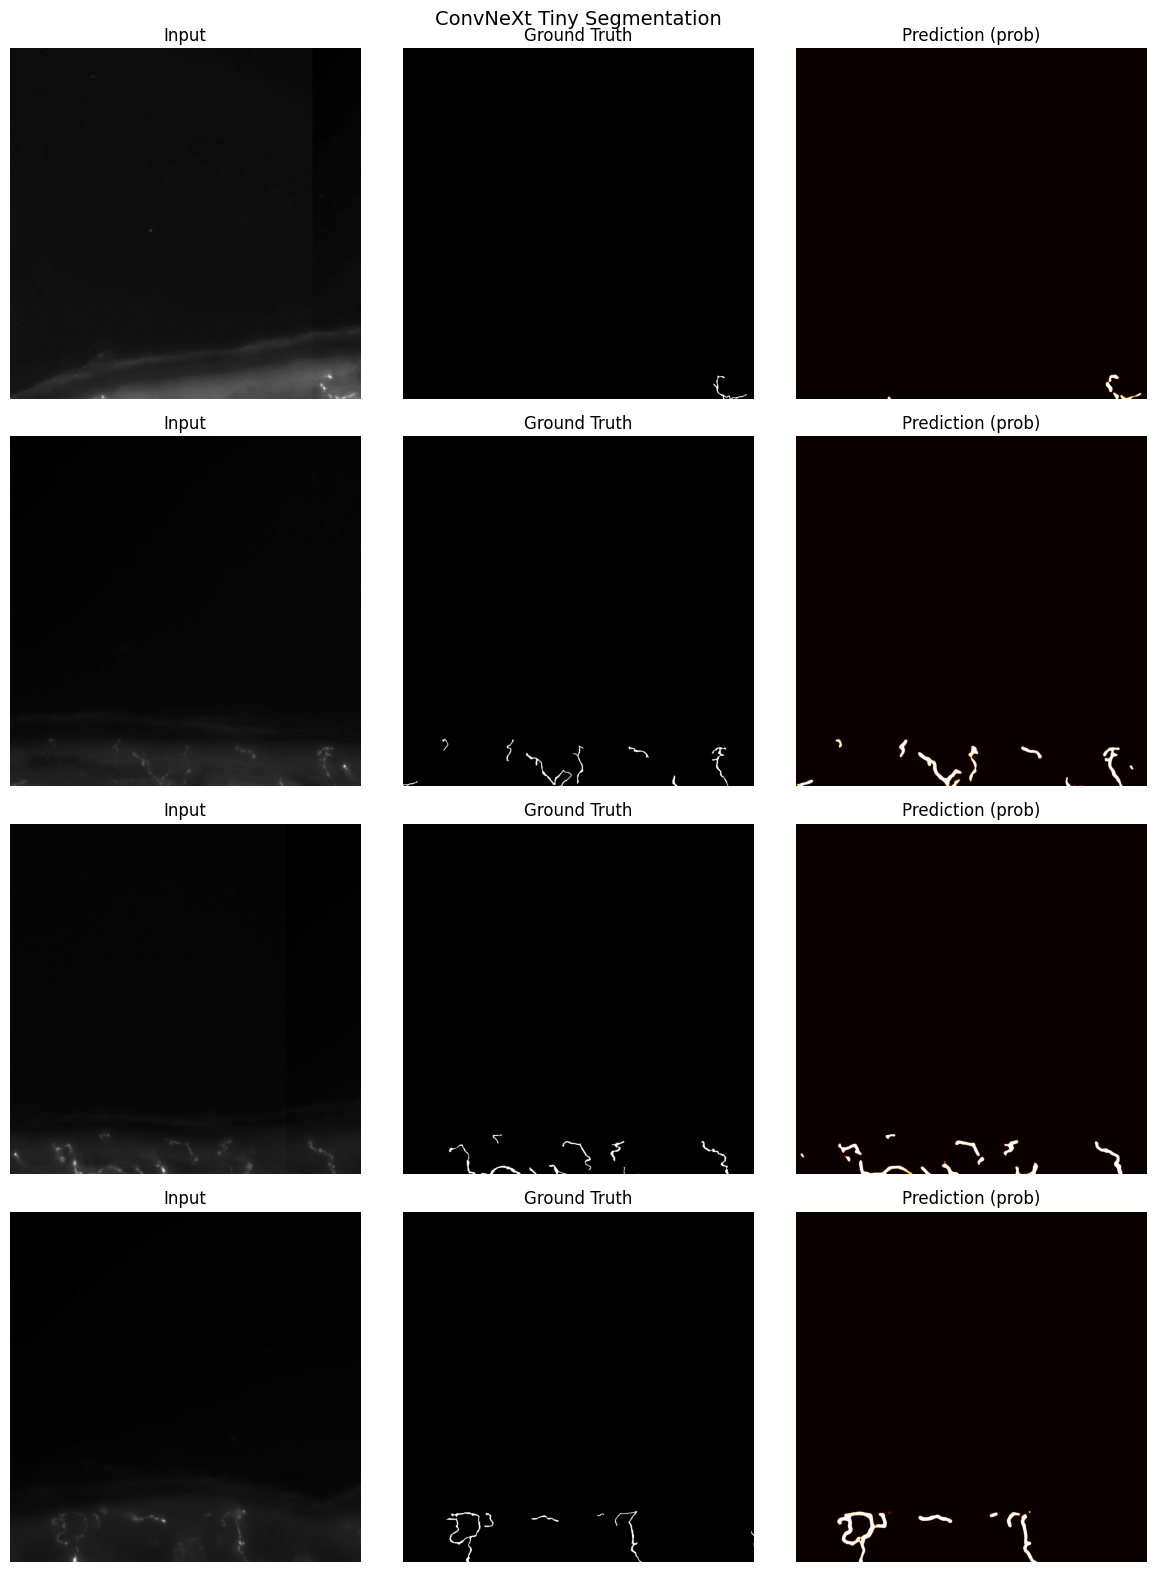

In [7]:
# Load best checkpoint
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Grab one val batch
x_batch, y_batch, _ = next(iter(val_loader))
x_batch = x_batch.to(DEVICE)

with torch.no_grad():
    logits = model(x_batch)
    prob   = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # (B, H, W)

n_show = min(4, x_batch.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis]

for i in range(n_show):
    img  = x_batch[i, 0].cpu().numpy()
    gt   = y_batch[i].numpy()
    pred = prob[i]

    axes[i, 0].imshow(img,  cmap='gray')
    axes[i, 0].set_title('Input')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt,   cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred, cmap='hot', vmin=0, vmax=1)
    axes[i, 2].set_title('Prediction (prob)')
    axes[i, 2].axis('off')

plt.suptitle('ConvNeXt Tiny Segmentation', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'predictions.png', dpi=150)
plt.show()

In [8]:

from neural_reconstruction.core.segmentation import (
    predict_full_image
)
def dice_np(pred_bin: np.ndarray, gt_bin: np.ndarray) -> float:
    intersection = (pred_bin & gt_bin).sum()
    total = pred_bin.sum() + gt_bin.sum()
    return float(2 * intersection / max(total, 1))

for sample_dir in valid_samples:
        img, _, lbl = load_sample(sample_dir)
        prob_map = predict_full_image(
            model, img, patch_size=PATCH_SIZE, stride=STRIDE, device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        pred_bin = prob_map > 0.5
        target_bin = lbl > 127
        d = dice_np(pred_bin, target_bin)
        # split = "train" if sample_dir in train_sample_dirs else "val"

        # all_dice.append(d)
        # (train_dice_vals if split == "train" else val_dice_vals).append(d)
        print(f"  {sample_dir.name:<20}  {d:.4f}")

  S1140-2_a             0.6471
  S1140-2_b             0.7318
  S1585-2_a             0.6585
  S1585-2_b             0.6383
  S1616-2_a             0.4515
  S222-2_a              0.5208
  S222-2_b              0.6363
  S226-2_a              0.7190
  S226-2_b              0.6920
  S236-2_a              0.7680
  S236-2_b              0.7564
  S341-2_a              0.7533
  S341-2_b              0.7658
  S487-2_a              0.7943
  S487-2_b              0.7631
  S558-2_a              0.8112
  S558-2_b              0.7943
